In [7]:
# Imports 

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, brier_score_loss
from xgboost import XGBClassifier


import matplotlib.pyplot as plt

In [3]:
# Load 
df = pd.read_csv("D:/Final Year/App Domains/Project/datasets/creditcard.csv")

In [4]:
# Quick Checks 
print(df.columns)
print(df[["Time", "Amount", "Class"]].describe())
print("Class counts:")
print(df["Class"].value_counts())

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')
                Time         Amount          Class
count  284807.000000  284807.000000  284807.000000
mean    94813.859575      88.349619       0.001727
std     47488.145955     250.120109       0.041527
min         0.000000       0.000000       0.000000
25%     54201.500000       5.600000       0.000000
50%     84692.000000      22.000000       0.000000
75%    139320.500000      77.165000       0.000000
max    172792.000000   25691.160000       1.000000
Class counts:
Class
0    284315
1       492
Name: count, dtype: int64


In [5]:
# Feture Enginneering, Static Model first 

feature_cols_static = [col for col in df.columns if col.startswith("V")]
feature_cols_static.append("Amount")

X_static = df[feature_cols_static].values
y = df["Class"].values

print("Number of static features:", len(feature_cols_static))

Number of static features: 29


In [6]:
# Randomised, static train/testing split 

X_train_static, X_test_static, y_train_static, y_test_static = train_test_split(
    X_static,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

print("Static train shape:", X_train_static.shape)
print("Static test shape:", X_test_static.shape)

Static train shape: (199364, 29)
Static test shape: (85443, 29)


In [8]:
# As we seen in the previous, XGBoost is considered our most accurate 
# So we will try and improve our already acclaimed best model

static_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",   # must include for XGBoost
        n_jobs=-1,
        scale_pos_weight= (y_train_static == 0).sum() / max((y_train_static == 1).sum(), 1)
    ))
])

In [9]:
# Fit static XGBoost  model and evaluate

static_pipeline.fit(X_train_static, y_train_static)

y_proba_static = static_pipeline.predict_proba(X_test_static)[:, 1]
y_pred_static  = (y_proba_static >= 0.5).astype(int)

auc_static   = roc_auc_score(y_test_static, y_proba_static)
acc_static   = accuracy_score(y_test_static, y_pred_static)
brier_static = brier_score_loss(y_test_static, y_proba_static)

print("=== Static model (random split, no Time) ===")
print(f"AUC   : {auc_static:.3f}")
print(f"Acc   : {acc_static:.3f}")
print(f"Brier : {brier_static:.4f}")


=== Static model (random split, no Time) ===
AUC   : 0.971
Acc   : 0.999
Brier : 0.0005


In [10]:
# Re Sort by Time for temporal setting

df_sorted = df.sort_values("Time").reset_index(drop=True)
df_sorted[["Time", "Class"]].head()


,Time,Class
0,0.0,0
1,0.0,0
2,1.0,0
3,1.0,0
4,2.0,0


In [11]:
# Prepare temporal features, includes Time now as a feature

feature_cols_temp = [col for col in df.columns if col.startswith("V")]
feature_cols_temp.extend(["Amount", "Time"])   

X_temp = df_sorted[feature_cols_temp].values
y_temp = df_sorted["Class"].values

print("Number of temporal features:", len(feature_cols_temp))


Number of temporal features: 30


In [12]:
# Temporal train/test split (train early in time, test later)

train_frac = 0.7
split_idx = int(len(df_sorted) * train_frac)

X_train_temp = X_temp[:split_idx]
y_train_temp = y_temp[:split_idx]
X_test_temp  = X_temp[split_idx:]
y_test_temp  = y_temp[split_idx:]

print("Temporal train shape:", X_train_temp.shape)
print("Temporal test shape:", X_test_temp.shape)

print("Train time range:", df_sorted["Time"].iloc[:split_idx].min(),
      "->", df_sorted["Time"].iloc[:split_idx].max())
print("Test time range :", df_sorted["Time"].iloc[split_idx:].min(),
      "->", df_sorted["Time"].iloc[split_idx:].max())


Temporal train shape: (199364, 30)
Temporal test shape: (85443, 30)
Train time range: 0.0 -> 132928.0
Test time range : 132929.0 -> 172792.0


In [14]:
# Define XGBoost pipeline for temporal model
# Must use same as static classification 

# Compute imbalance ratio for scale_pos_weight
neg_temp = (y_train_temp == 0).sum()
pos_temp = (y_train_temp == 1).sum()
imbalance_ratio_temp = neg_temp / max(pos_temp, 1)

temp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",   # required to suppress eval warnings
        n_jobs=-1,
        scale_pos_weight=imbalance_ratio_temp   # handles class imbalance properly
    ))
])

In [15]:
# Fit temporal model and evaluate

temp_pipeline.fit(X_train_temp, y_train_temp)

y_proba_temp = temp_pipeline.predict_proba(X_test_temp)[:, 1]
y_pred_temp  = (y_proba_temp >= 0.5).astype(int)

auc_temp   = roc_auc_score(y_test_temp, y_proba_temp)
acc_temp   = accuracy_score(y_test_temp, y_pred_temp)
brier_temp = brier_score_loss(y_test_temp, y_proba_temp)

print("=== Temporal model (time-based split, Time included) ===")
print(f"AUC   : {auc_temp:.3f}")
print(f"Acc   : {acc_temp:.3f}")
print(f"Brier : {brier_temp:.4f}")


=== Temporal model (time-based split, Time included) ===
AUC   : 0.984
Acc   : 1.000
Brier : 0.0004


In [16]:
# Compare static vs temporal

results = pd.DataFrame({
    "Model": ["Static (random, no Time)", "Temporal (time split, +Time)"],
    "AUC":   [auc_static, auc_temp],
    "Accuracy": [acc_static, acc_temp],
    "Brier": [brier_static, brier_temp]
})

results


,Model,AUC,Accuracy,Brier
0,"Static (random, no Time)",0.970569,0.999403,0.000543
1,"Temporal (time split, +Time)",0.983892,0.999555,0.000418


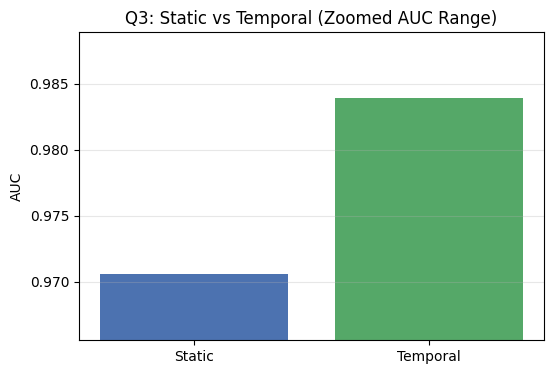

In [18]:
plt.figure(figsize=(6, 4))
plt.bar(["Static", "Temporal"], [auc_static, auc_temp], color=["#4C72B0", "#55A868"])

plt.ylabel("AUC")
plt.title("Q3: Static vs Temporal (Zoomed AUC Range)")

auc_min = min(auc_static, auc_temp) - 0.005
auc_max = max(auc_static, auc_temp) + 0.005
plt.ylim(auc_min, auc_max)

plt.grid(axis="y", alpha=0.3)
plt.show()


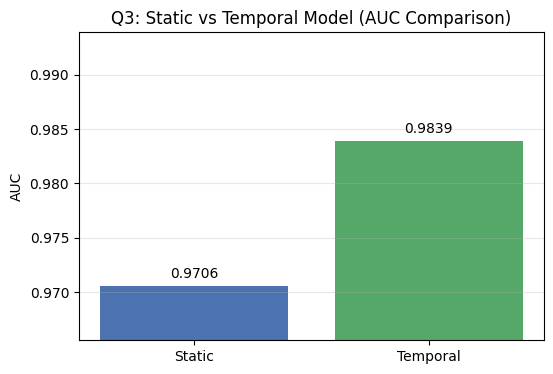

In [19]:
plt.figure(figsize=(6, 4))
bars = plt.bar(["Static", "Temporal"], [auc_static, auc_temp], color=["#4C72B0", "#55A868"])

plt.ylabel("AUC")
plt.title("Q3: Static vs Temporal Model (AUC Comparison)")

# Annotate exact values
for bar, val in zip(bars, [auc_static, auc_temp]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
             f"{val:.4f}", ha="center", va="bottom", fontsize=10)

plt.ylim(min(auc_static, auc_temp) - 0.005, max(auc_static, auc_temp) + 0.01)
plt.grid(axis="y", alpha=0.3)
plt.show()


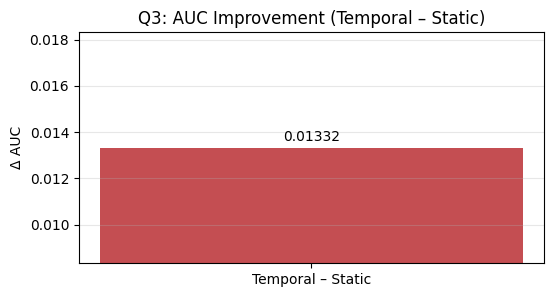

In [20]:
auc_diff = auc_temp - auc_static

plt.figure(figsize=(6, 3))
plt.bar(["Temporal – Static"], [auc_diff], color="#C44E52")

plt.ylabel("Δ AUC")
plt.title("Q3: AUC Improvement (Temporal – Static)")

# Zoom around zero
plt.ylim(auc_diff - 0.005, auc_diff + 0.005)

# Show number above bar
plt.text(0, auc_diff + 0.0003, f"{auc_diff:.5f}", ha="center", fontsize=10)

plt.axhline(0, color="black", linewidth=0.8)
plt.grid(axis="y", alpha=0.3)
plt.show()
